# 1 Многоклассовая регрессия для предсказания кластера

Бизнес-цель: Автоматическая категоризация новых игроков в уже выделенные кластеры (например, при скаутинге).

Пример: Скаут нашел  молодого полузащитника с неизвестным потенциалом — модель может отнести его к одному из кластеров (например, "универсалы" или "атакующие полузащитники"), что поможет понять его стиль игры и ценность.

In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                            confusion_matrix, 
                            accuracy_score,
                            f1_score)
from sklearn.inspection import permutation_importance
import shap

### Загрузка данных

In [43]:
df = pd.read_csv('C:\\Users\\e617k\\Desktop\\Пиитон экзамен\\output.csv')
df.head()

,ID,name,Team & Contract,Age,Best position,Value,Potential,Overall rating,Wage,Release clause,International reputation,Total stats,Growth,Total movement,Total power,Total mentality,Total skill,Total defending,Total goalkeeping,Total attacking,Position group,Cluster
0,28130,15 Ronaldinho CAM ST,Querétaro\n2014 ~ 2016,34,CAM,4100000.0,78,78,45000.0,0.0,3,1875,0,313,314,319,430,78,54,367,Midfield,1
1,240740,C. Hudson-Odoi LM LW RW,Nottingham Forest\n2023 ~ 2026,22,RM,11500000.0,81,76,49000.0,22700000.0,2,1921,5,388,335,291,376,143,58,330,Midfield,1
2,220139,S. Szmodics CAM ST,Blackburn Rovers\n2022 ~ 2026,27,CAM,6000000.0,75,75,40000.0,11400000.0,1,2003,0,410,356,343,347,141,62,344,Midfield,1
3,257057,A. Onana CDM CM,Everton\n2022 ~ 2027,21,CDM,15500000.0,83,77,26000.0,32600000.0,1,1954,6,333,369,332,323,227,50,320,Midfield,1
4,254796,N. Madueke RM RW,Chelsea\n2023 ~ 2030,21,CAM,15000000.0,83,76,60000.0,31500000.0,1,1885,7,416,346,284,368,102,51,318,Midfield,1


In [44]:
print(f"Полузащитников: {len(df)}")
print("\nУникальные кластеры:", sorted(df['Cluster'].unique()))

Полузащитников: 1108

Уникальные кластеры: [1, 2, 3, 4, 5, 6, 7, 8]


In [45]:
# Выбор признаков для модели 
features = [
    "Value", 
    "Potential",
    "Age",
    "Overall rating",
    "Wage",
    "International reputation",
    "Growth",
    "Total movement",
    "Total mentality",
    "Total defending",
    "Total goalkeeping",
    "Total attacking"
]

X = df[features]
y = df['Cluster']  # Кластеры 1-8

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

### Анализ линейности факторов

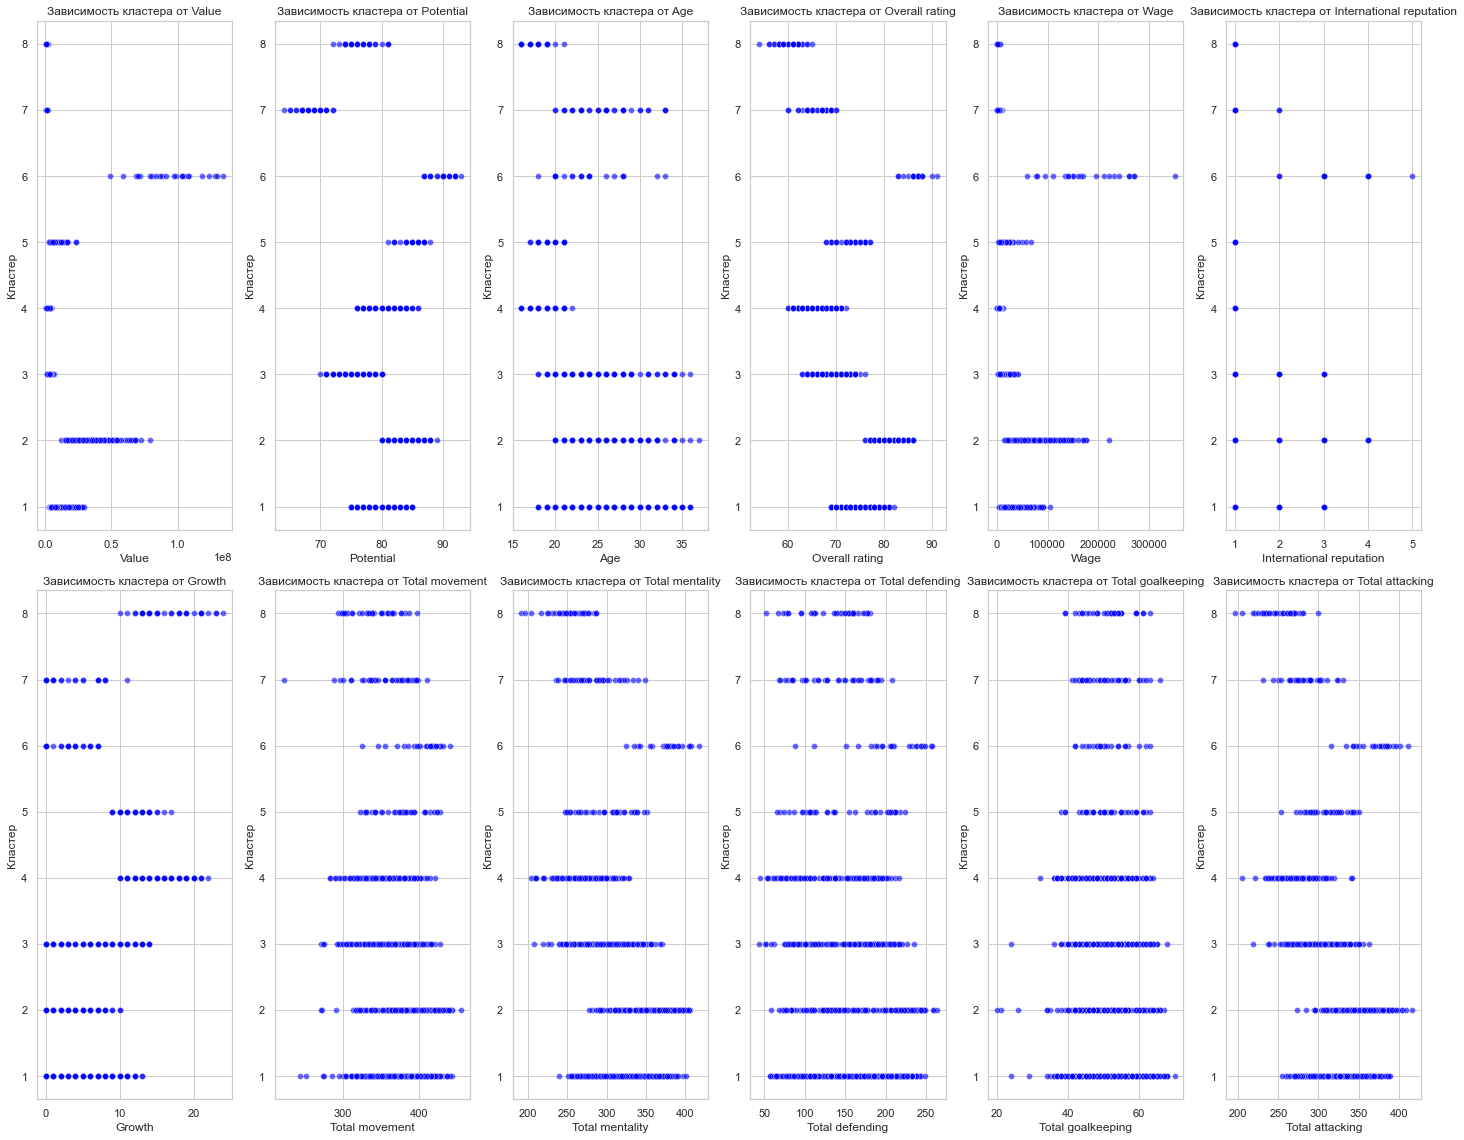

In [46]:
# Настройка стиля графиков
sns.set(style="whitegrid")
plt.figure(figsize=(20, 16))
# Список признаков
# Построение диаграмм рассеяния для каждого признака
for i, feature in enumerate(features, 1):
    plt.subplot(2, 6, i)
    sns.scatterplot(data=df, x=feature, y='Cluster', alpha=0.6, color='blue')
    plt.title(f'Зависимость кластера от {feature}')
    plt.xlabel(feature)
    plt.ylabel('Кластер')

plt.tight_layout()
plt.show()

### Моделирование -> Random Forest

Для задачи предсказания кластеров футболистов (значения от 1 до 8) буду использовать Random Forest по следующим причинам:
- Учет нелинейностей - RF автоматически учитывает сложные нелинейные зависимости между признаками
- Устойчивость к переобучению - благодаря бэггингу и случайному выбору признаков
- Интерпретируемость - можно анализировать важность признаков
- Работа с категориальными целевыми переменными - идеально подходит для задачи классификации

In [47]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nТренировочная выборка: {len(X_train)} записей")
print(f"Тестовая выборка: {len(X_test)} записей")


Тренировочная выборка: 886 записей
Тестовая выборка: 222 записей


In [48]:
# Инициализация модели Random Forest
rf = RandomForestClassifier(
    n_estimators=200,       # Количество деревьев (достаточно большое для стабильности)
    max_depth=10,           # Ограничение глубины для предотвращения переобучения
    min_samples_split=5,    # Минимальное количество образцов для разделения узла
    min_samples_leaf=2,     # Минимальное количество образцов в листе
    max_features='sqrt',    # Количество признаков для рассмотрения при разделении
    random_state=42,        # Для воспроизводимости
    class_weight='balanced', # Учет дисбаланса классов
    n_jobs=-1               # Использование всех ядер процессора
)

In [49]:
# Обучение модели
rf.fit(X_train, y_train)

# Предсказание на тестовых данных
y_pred = rf.predict(X_test)

# Оценка модели
print("\nОценка модели Random Forest:")
print(classification_report(y_test, y_pred))


Оценка модели Random Forest:
              precision    recall  f1-score   support

           1       0.92      0.98      0.95        94
           2       0.89      0.91      0.90        34
           3       0.97      0.89      0.93        37
           4       0.91      0.97      0.94        31
           5       1.00      0.62      0.77         8
           6       1.00      0.50      0.67         4
           7       1.00      0.86      0.92         7
           8       0.86      0.86      0.86         7

    accuracy                           0.92       222
   macro avg       0.94      0.82      0.87       222
weighted avg       0.93      0.92      0.92       222



ЯИнтерпретация метрик:
- precision -> Из всех объектов, которые модель предсказала как принадлежащие к данному классу, какая доля из них действительно принадлежит к этому классу?
- recall -> Из всех объектов, которые на самом деле принадлежат к данному классу, какая доля из них была правильно предсказана моделью?
- F1-score -> Оценивает баланс между точностью и полнотой. Высокий F1-score означает, что модель хорошо справляется и с точностью, и с полнотой.
- support ->  Показывает, насколько хорошо представлен данный класс в тестовом наборе. Маленький support может означать, что метрики для этого класса менее надежны, поскольку они основаны на небольшом количестве данных.
- macro avg -> Вычисляет метрику (precision, recall, f1-score) для каждого класса, а затем усредняет эти значения без учета количества объектов в каждом классе.
- weighted avg -> Вычисляет метрику (precision, recall, f1-score) для каждого класса, а затем усредняет эти значения, учитывая количество объектов в каждом классе (support).

Кластер 1: Отличные показатели (F1=0.95) - модель хорошо идентифицирует этот кластер

Кластеры 5 и 6: Низкий recall (0.62 и 0.50) - модель пропускает часть этих игроков

Кластер 8: Хорошие показатели, несмотря на малое количество примеров

Общая точность (accuracy): 0.92 - отличный результат

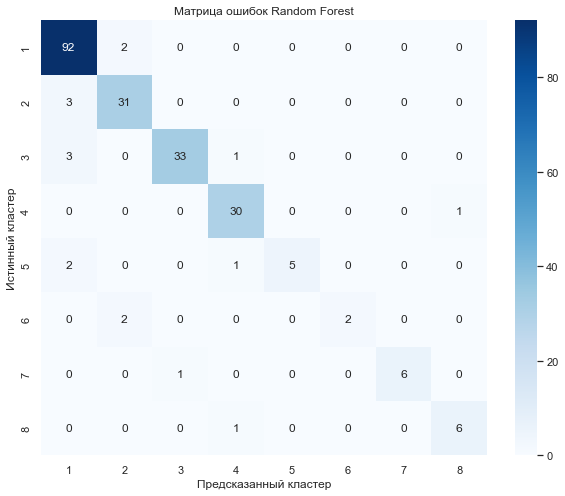

array([[92,  2,  0,  0,  0,  0,  0,  0],
       [ 3, 31,  0,  0,  0,  0,  0,  0],
       [ 3,  0, 33,  1,  0,  0,  0,  0],
       [ 0,  0,  0, 30,  0,  0,  0,  1],
       [ 2,  0,  0,  1,  5,  0,  0,  0],
       [ 0,  2,  0,  0,  0,  2,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  6,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  6]], dtype=int64)

In [54]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(1, 9), yticklabels=range(1, 9))
plt.xlabel('Предсказанный кластер')
plt.ylabel('Истинный кластер')
plt.title('Матрица ошибок Random Forest')
plt.show()

cm

Основные ошибки:

Кластер 1 иногда путается с 2 и 3

Кластер 5 иногда классифицируется как 1 или 4

Кластер 6 часто ошибочно относят к кластеру 2

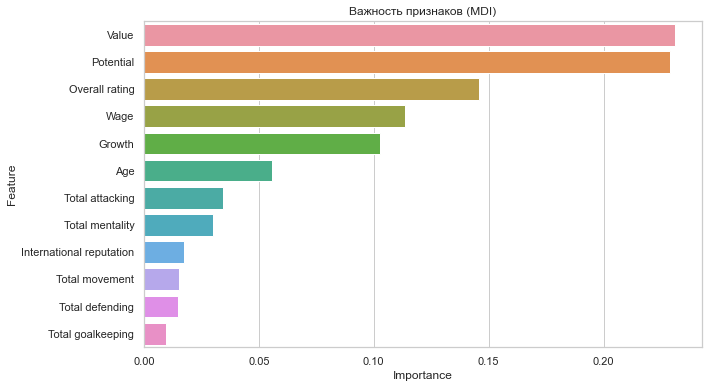

In [51]:
# Важность признаков (на основе среднего уменьшения нечистоты)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Важность признаков (MDI)')
plt.show()

In [55]:
feature_importance

,Feature,Importance
0,Value,0.231173
1,Potential,0.229019
3,Overall rating,0.145693
4,Wage,0.113738
6,Growth,0.102647
2,Age,0.055718
11,Total attacking,0.034552
8,Total mentality,0.029939
5,International reputation,0.017579
7,Total movement,0.015444


## Практический пример использования модели для принятия трансферного решения

In [70]:
# Данные игрока A (молодой перспективный)
player_A = {
    'Value': 12_000_000,
    'Potential': 85,
    'Age': 21,
    'Overall rating': 76,
    'Wage': 25_000,
    'International reputation': 2,
    'Growth': 9,
    'Total movement': 340,
    'Total mentality': 315,
    'Total defending': 150,
    'Total goalkeeping': 45,
    'Total attacking': 355
}

# Данные игрока B (опытный игрок)
player_B = {
    'Value': 20_000_000,
    'Potential': 82,
    'Age': 30,
    'Overall rating': 84,
    'Wage': 75_000,
    'International reputation': 3,
    'Growth': 2,
    'Total movement': 365,
    'Total mentality': 345,
    'Total defending': 185,
    'Total goalkeeping': 50,
    'Total attacking': 370
}

In [71]:
new_players = pd.DataFrame([player_A, player_B])

# Масштабируем данные как при обучении модели
new_players_scaled = scaler.transform(new_players)

In [73]:
# Предсказание кластеров
predicted_clusters = rf.predict(new_players_scaled)
print(f"Предсказанные кластеры: {predicted_clusters}")

# Вероятности принадлежности к кластерам
probabilities = rf.predict_proba(new_players_scaled)

Предсказанные кластеры: [1 2]


c:\Users\e617k\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\e617k\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [74]:
# Смотрим средние показатели для этих кластеров
df[df['Cluster'] == 1].describe()

,ID,Age,Value,Potential,Overall rating,Wage,Release clause,International reputation,Total stats,Growth,Total movement,Total power,Total mentality,Total skill,Total defending,Total goalkeeping,Total attacking,Cluster
count,468.000000,468.000000,4.680000e+02,468.000000,468.000000,468.000000,4.680000e+02,468.00000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.00000,468.000000,468.0
mean,239397.134615,24.151709,1.032479e+07,79.974359,75.316239,29335.470085,1.721944e+07,1.34188,1951.425214,4.698718,373.792735,348.373932,327.442308,354.683761,171.166667,50.74359,325.222222,1.0
std,28093.140195,3.663650,5.903193e+06,2.542863,2.731840,17900.410388,1.266886e+07,0.58037,110.371151,3.718269,30.461577,28.370732,30.744281,27.045888,48.294843,6.89897,25.534663,0.0
min,7826.000000,18.000000,2.700000e+06,75.000000,69.000000,5000.000000,0.000000e+00,1.00000,1665.000000,0.000000,245.000000,250.000000,240.000000,275.000000,57.000000,24.00000,254.000000,1.0
25%,231739.000000,21.000000,5.500000e+06,78.000000,73.000000,16000.000000,8.400000e+06,1.00000,1875.000000,1.000000,355.000000,329.000000,308.000000,335.000000,132.750000,46.00000,307.000000,1.0
50%,243074.000000,23.000000,9.000000e+06,80.000000,75.000000,25500.000000,1.490000e+07,1.00000,1950.000000,5.000000,376.000000,347.000000,330.000000,355.000000,186.500000,50.50000,326.000000,1.0
75%,256739.250000,26.000000,1.400000e+07,82.000000,77.000000,38000.000000,2.422500e+07,2.00000,2036.000000,8.000000,396.250000,369.000000,350.000000,373.250000,211.000000,55.00000,343.000000,1.0
max,278069.000000,36.000000,2.900000e+07,85.000000,82.000000,105000.000000,6.200000e+07,3.00000,2208.000000,13.000000,443.000000,430.000000,401.000000,430.000000,249.000000,70.00000,389.000000,1.0


In [75]:
df[df['Cluster'] == 2].describe()

,ID,Age,Value,Potential,Overall rating,Wage,Release clause,International reputation,Total stats,Growth,Total movement,Total power,Total mentality,Total skill,Total defending,Total goalkeeping,Total attacking,Cluster
count,170.000000,170.000000,1.700000e+02,170.000000,170.000000,170.000000,1.700000e+02,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.0
mean,226550.252941,25.952941,3.480000e+07,84.176471,81.511765,80411.764706,6.232882e+07,2.264706,2085.647059,2.705882,385.082353,371.035294,355.029412,385.829412,182.100000,50.541176,356.029412,2.0
std,27334.919239,3.769720,1.262282e+07,2.070797,2.272132,38845.557990,2.886020e+07,0.894057,105.204980,2.842299,34.085244,27.931424,30.925263,27.966808,54.652496,7.911572,25.811659,0.0
min,10535.000000,20.000000,1.200000e+07,80.000000,76.000000,14000.000000,0.000000e+00,1.000000,1831.000000,0.000000,272.000000,272.000000,278.000000,303.000000,59.000000,20.000000,273.000000,2.0
25%,211381.000000,23.000000,2.650000e+07,83.000000,80.000000,53250.000000,4.720000e+07,2.000000,2024.750000,0.000000,368.000000,355.000000,336.000000,368.000000,136.000000,46.000000,342.000000,2.0
50%,231806.500000,25.000000,3.100000e+07,84.000000,82.000000,74000.000000,6.005000e+07,2.000000,2098.000000,2.000000,389.500000,374.500000,360.000000,387.000000,200.000000,50.000000,358.000000,2.0
75%,244594.000000,29.000000,4.187500e+07,86.000000,83.000000,105000.000000,8.025000e+07,3.000000,2154.500000,5.000000,407.000000,390.000000,378.000000,405.750000,231.750000,56.000000,375.000000,2.0
max,272449.000000,37.000000,7.950000e+07,89.000000,86.000000,220000.000000,1.411000e+08,4.000000,2312.000000,10.000000,455.000000,429.000000,406.000000,442.000000,263.000000,67.000000,417.000000,2.0


# 2 Регрессия: Прогнозирование потенциала (Growth)

#### Прогнозирование потенциала (Growth) — регрессия
#### Бизнес-цель
Спрогнозировать потенциал роста (Growth) футболистов на основе их текущих характеристик, чтобы:
- Находить недооцененных игроков с высоким потенциалом для покупки.
- Развивать ключевые навыки у текущих игроков.
- Снижать риски ошибочных инвестиций в игроков с низким потенциалом.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate


import shap

In [2]:
df = pd.read_csv('C:\\Users\\e617k\\Desktop\\Пиитон экзамен\\players_stats.csv')
df.head()

,name,Age,Overall rating,Potential,Team & Contract,ID,Height,Weight,foot,Best overall,...,GK Reflexes,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Unnamed: 64
0,15 Ronaldinho CAM ST,34,78,78,Querétaro\n2014 ~ 2016,28130,"182cm / 6'0""",76kg / 168lbs,Right,77,...,14,1875,377,3,49,72,83,84,28,NaN
1,O. Hutchinson RM CAM,19,65,81,Ipswich Town\n2022 ~ 2025,260145,"174cm / 5'9""",65kg / 143lbs,Left,67,...,8,1651,351,1,72,54,61,70,44,NaN
2,Brahim CAM,23,82,86,Real Madrid\n2019 ~ 2027,231410,"170cm / 5'7""",68kg / 150lbs,Right,84,...,6,1897,409,1,85,74,78,85,31,NaN
3,K. Wätjen CM,17,62,80,Borussia Dortmund\n2024 ~ 2028,70728,"178cm / 5'10""",72kg / 159lbs,Right,65,...,8,1644,353,1,72,50,59,66,52,NaN
4,A. Güler CAM RM,18,77,88,Real Madrid\n2023 ~ 2029,264309,"175cm / 5'9""",70kg / 154lbs,Left,79,...,10,1960,405,1,72,70,80,81,52,NaN


In [3]:
df = df[df['Best position'] != 'GK']

In [4]:
def calculate_potential(value):
    # Если значение уже число - возвращаем как есть
    if isinstance(value, (int, float)):
        return int(value)
    
    # Если значение - строка, обрабатываем модификаторы
    if isinstance(value, str):
        value = str(value).strip()  # На случай пробелов
        # Если есть модификатор (например, '87-2', '81+3')
        if '-' in value or '+' in value:
            # Разделяем основное число и модификатор
            main_value = int(''.join(filter(str.isdigit, value.split('-')[0].split('+')[0])))
            modifier = value.replace(str(main_value), '')  # Извлекаем модификатор
            # Вычисляем итоговый потенциал
            if '-' in modifier:
                return main_value - int(modifier.replace('-', ''))
            elif '+' in modifier:
                return main_value + int(modifier.replace('+', ''))
        # Если модификатора нет, пытаемся преобразовать в число
        try:
            return int(value)
        except ValueError:
            return 0  # или другое значение по умолчанию
    # Для других типов (например, None) возвращаем 0
    return 0

In [5]:
columns_to_process = [
    'Age'

    #,'Total attacking'
    ,'Crossing'
    , 'Finishing'
    , 'Heading accuracy'
    , 'Short passing'
    , 'Volleys'
    
    #,'Total skill'
    , 'Dribbling'
    , 'Curve'
    , 'FK Accuracy'
    , 'Long passing'
    , 'Ball control'
    
    #,'Total movement'
    , 'Acceleration'
    , 'Sprint speed'
    , 'Agility'
    , 'Reactions'
    , 'Balance'
    
    #,'Total power'
    , 'Shot power'
    , 'Jumping'
    , 'Stamina'
    , 'Strength'
    , 'Long shots'
    
    #, 'Total mentality'
    , 'Aggression'
    , 'Interceptions'
    , 'Att. Position'
    , 'Vision'
    , 'Penalties'
    , 'Composure'
    
    #, 'Total defending'
    , 'Defensive awareness'
    , 'Standing tackle'
    , 'Sliding tackle'
    
    #,'Total goalkeeping'
    #, 'GK Diving'
    #, 'GK Handling'
    #, 'GK Kicking'
    #, 'GK Positioning'
    #, 'GK Reflexes'
    
    #,'Total stats'
    #, 'Base stats'
    , 'International reputation'
    , 'Pace / Diving'
    , 'Shooting / Handling'
    , 'Passing / Kicking'
    , 'Dribbling / Reflexes'
    , 'Defending / Pace'
]

# Применяем функцию к указанным столбцам
for column in columns_to_process:
    df[column] = df[column].apply(calculate_potential)

# (Опционально) Проверяем результат:
df[columns_to_process].head()  # Выводим первые несколько строк обработанных столбцов

,Age,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Dribbling,Curve,FK Accuracy,Long passing,...,Composure,Defensive awareness,Standing tackle,Sliding tackle,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace
0,34,84,69,50,82,82,86,86,87,81,...,0,25,28,25,3,49,72,83,84,28
1,19,48,53,49,66,50,69,52,50,65,...,63,40,49,51,1,72,54,61,70,44
2,23,75,76,30,83,64,84,74,61,75,...,79,40,23,21,1,85,74,78,85,31
3,17,48,53,45,67,44,66,52,43,65,...,49,50,55,56,1,72,50,59,66,52
4,18,80,68,41,81,70,83,84,76,79,...,77,52,57,46,1,72,70,80,81,52


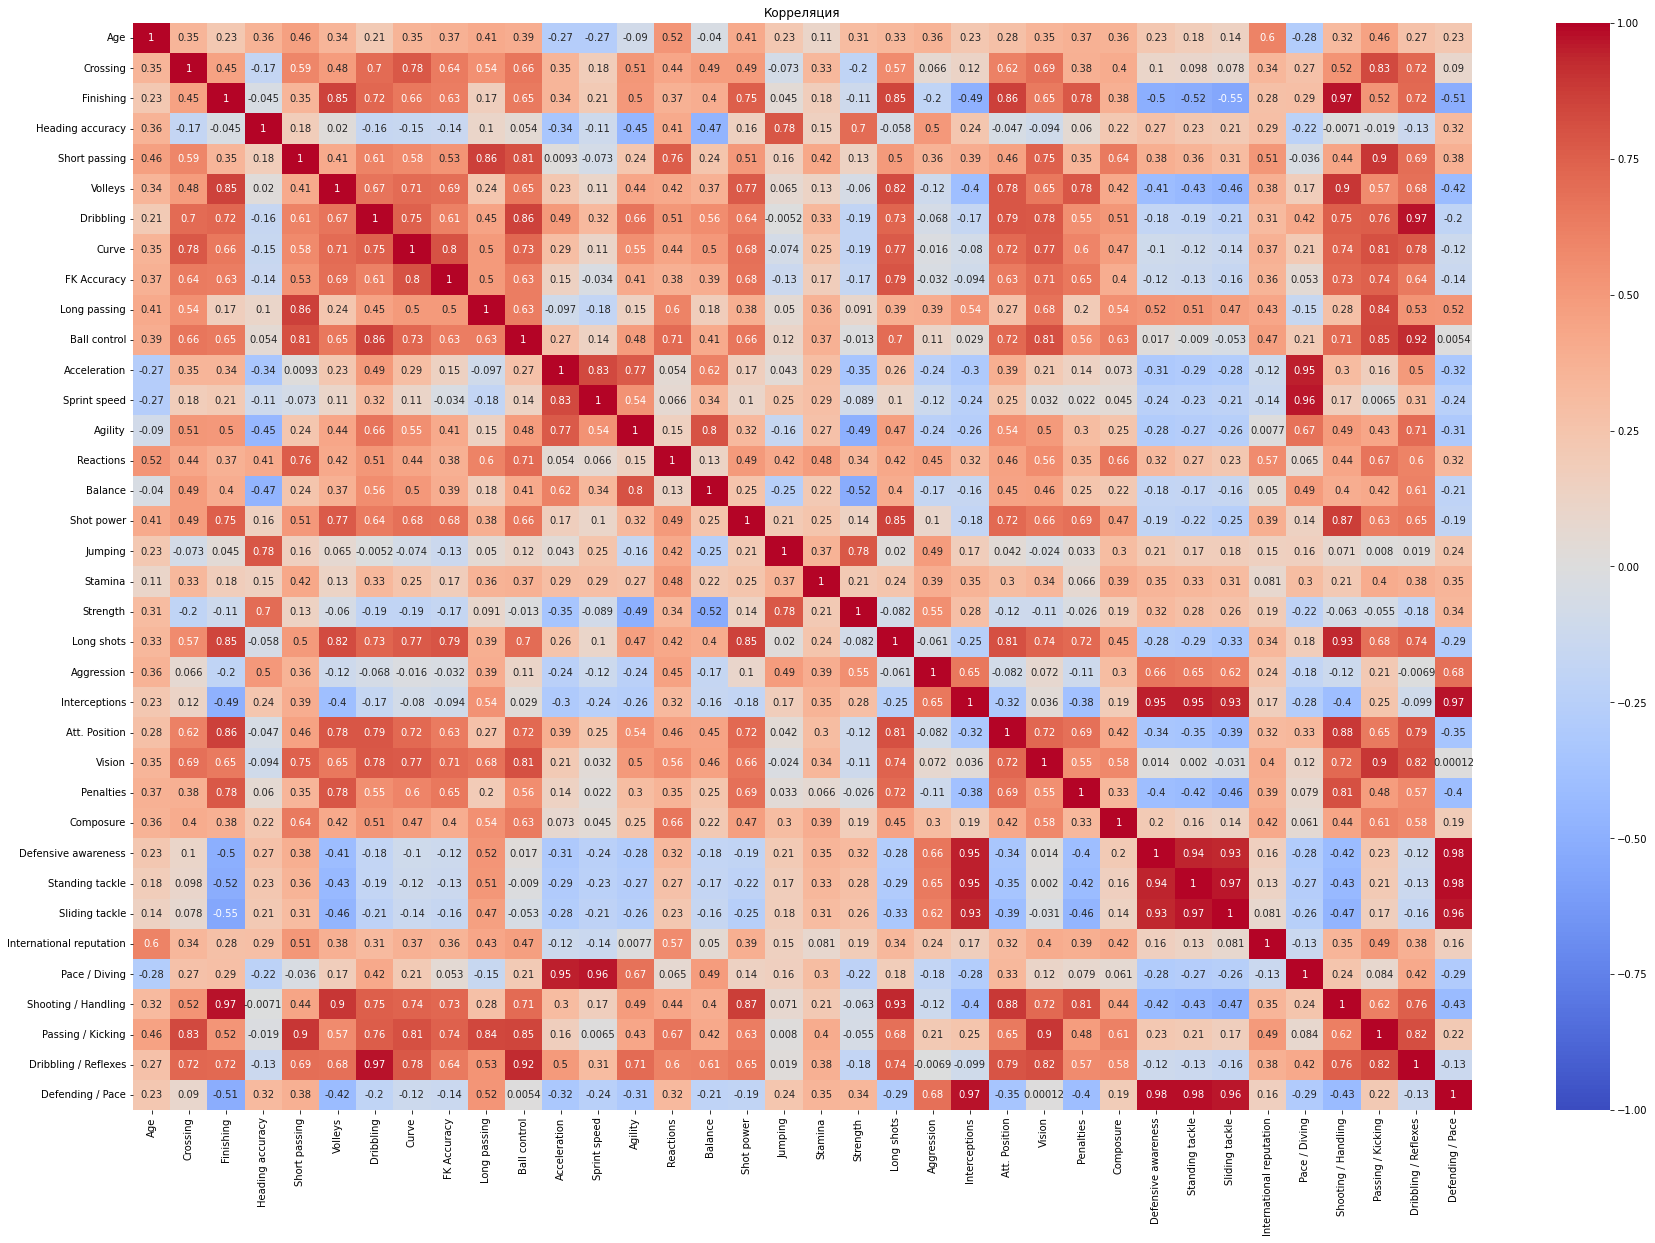

In [6]:
# Вычисляем корреляции
corr = df[columns_to_process].corr()
# Визуализация
plt.figure(figsize=(30, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция')
plt.show()

Gradient Boosting (как и другие ML-алгоритмы) может показывать разное качество на разных подмножествах данных. Кросс-валидация дает усредненную и устойчивую оценку:
- Разбивает данные на k частей (например, 5).
- k-1 частей — на обучение, 1 — на тест.
- Повторяет процесс k раз, меняя тестовую часть.
- Усредняет метрики (R², MAE и др.) по всем прогонам.

In [7]:
X = df[columns_to_process]
y = df['Growth']  # Целевая переменная

# Инициализация модели
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    subsample=0.8,  # Дополнительная защита от переобучения
    max_features='sqrt'  # Рассматриваем случайное подмножество признаков в каждом узле
)

# Кросс-валидация
scores = cross_val_score(gbr, X, y, cv=5, scoring='r2')
print(f"R2 score: {scores.mean():.3f} ± {scores.std():.3f}")

# Обучение модели на всех данных
gbr.fit(X, y)

R2 score: 0.914 ± 0.017


GradientBoostingRegressor(learning_rate=0.05, max_depth=5, max_features='sqrt',
                          n_estimators=200, random_state=42, subsample=0.8)

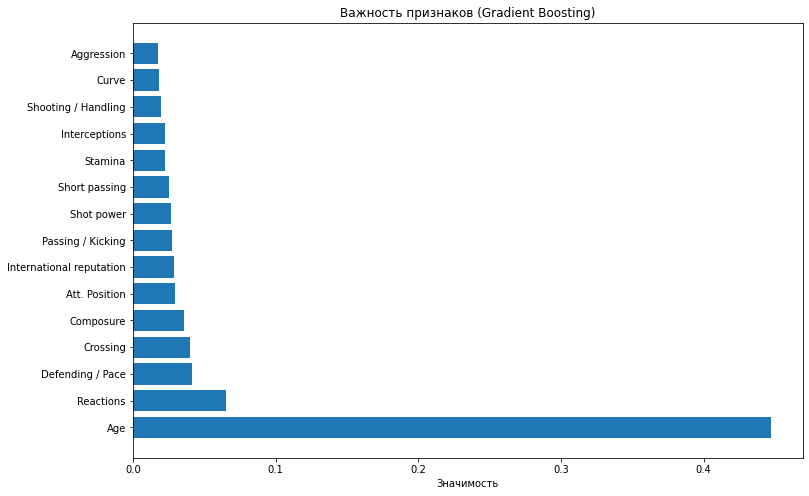

In [8]:
# Анализ важности признаков
feat_importance = pd.DataFrame({
    'Feature': columns_to_process,
    'Importance': gbr.feature_importances_
}).sort_values('Importance', ascending=False)

# Визуализация важности 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.barh(feat_importance['Feature'][:15], feat_importance['Importance'][:15])
plt.title('Важность признаков (Gradient Boosting)')
plt.xlabel('Значимость')
plt.show()

In [9]:
# Топ важных признаков
feat_importance.head(20)

,Feature,Importance
0,Age,0.446976
14,Reactions,0.065434
35,Defending / Pace,0.041481
1,Crossing,0.040306
26,Composure,0.035581
23,Att. Position,0.029362
30,International reputation,0.028677
33,Passing / Kicking,0.027071
16,Shot power,0.026541
4,Short passing,0.025447


## Без Age

In [141]:
columns_to_process = [
    #'Age'

    #,'Total attacking'
    'Crossing'
    , 'Finishing'
    , 'Heading accuracy'
    , 'Short passing'
    , 'Volleys'
    
    #,'Total skill'
    , 'Dribbling'
    , 'Curve'
    , 'FK Accuracy'
    , 'Long passing'
    , 'Ball control'
    
    #,'Total movement'
    , 'Acceleration'
    , 'Sprint speed'
    , 'Agility'
    , 'Reactions'
    , 'Balance'
    
    #,'Total power'
    , 'Shot power'
    , 'Jumping'
    , 'Stamina'
    , 'Strength'
    , 'Long shots'
    
    #, 'Total mentality'
    , 'Aggression'
    , 'Interceptions'
    , 'Att. Position'
    , 'Vision'
    , 'Penalties'
    , 'Composure'
    
    #, 'Total defending'
    , 'Defensive awareness'
    , 'Standing tackle'
    , 'Sliding tackle'
    
    #,'Total goalkeeping'
    #, 'GK Diving'
    #, 'GK Handling'
    #, 'GK Kicking'
    #, 'GK Positioning'
    #, 'GK Reflexes'
    
    #,'Total stats'
    #, 'Base stats'
    , 'International reputation'
    , 'Pace / Diving'
    , 'Shooting / Handling'
    , 'Passing / Kicking'
    , 'Dribbling / Reflexes'
    , 'Defending / Pace'
]

In [129]:
X = df[columns_to_process]
y = df['Growth']  # Целевая переменная


# Кросс-валидация
scores = cross_val_score(gbr, X, y, cv=5, scoring='r2')
print(f"R2 score: {scores.mean():.3f} ± {scores.std():.3f}")

# Обучение модели на всех данных
gbr.fit(X, y)

R2 score: 0.570 ± 0.147


GradientBoostingRegressor(learning_rate=0.05, max_depth=5, max_features='sqrt',
                          n_estimators=200, random_state=42, subsample=0.8)


Топ-10 важных признаков:
                     Feature  Importance
13                 Reactions    0.171262
0                   Crossing    0.063574
32         Passing / Kicking    0.055820
22             Att. Position    0.050873
29  International reputation    0.046919
17                   Stamina    0.044663
9               Ball control    0.038282
20                Aggression    0.037295
18                  Strength    0.036658
2           Heading accuracy    0.035243


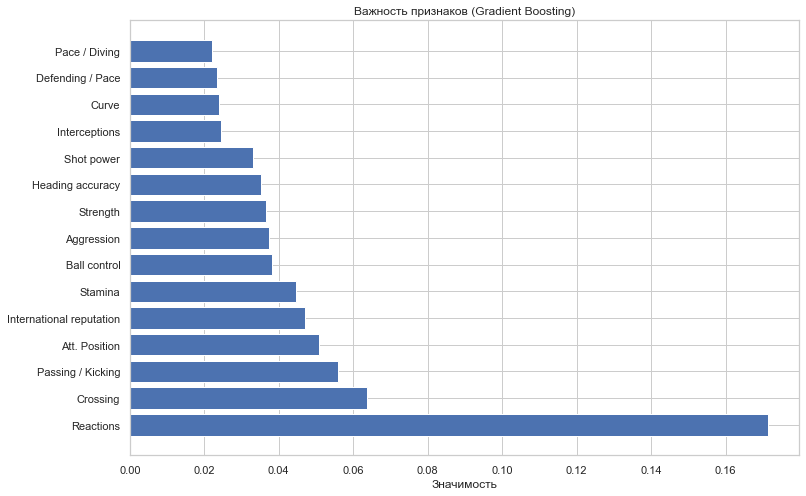

In [130]:
# Анализ важности признаков
feat_importance = pd.DataFrame({
    'Feature': columns_to_process,
    'Importance': gbr.feature_importances_
}).sort_values('Importance', ascending=False)

# Топ-10 важных признаков
print("\nТоп-10 важных признаков:")
print(feat_importance.head(10))

# Визуализация важности 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.barh(feat_importance['Feature'][:15], feat_importance['Importance'][:15])
plt.title('Важность признаков (Gradient Boosting)')
plt.xlabel('Значимость')
plt.show()

### Рекомендации:
1. Для скаутов: добавить приоритетные критерии -> Age < 22', 'Reactions > 70', 'Crossing > 65

2. Для тренеров:
- Развивать Reactions и Crossing — они сильнее всего влияют на Growth.
- Игрокам после 25 лет делать упор на International reputation (медийность, репутацию) и виносливость.

Для аналитиков:
- добавить новые признаки, минуты на поле в прошлом сезоне.
- Травматичность (битые/небитые)


Высокий R² (0.914) может указывать на утечку данных (например, если Growth косвенно учитывает Age при расчете)

Модель помогает находить перспективных игроков и оптимизировать тренировочный процесс.

#### Пример бизнес-решения

In [151]:
# Критерии отбора (создаем копию датафрейма)
target_players = df[
    (df['Age'] < 23) & 
    (df['Reactions'] > 75) & 
    (df['Passing / Kicking'] > 70)
].copy()  # Добавляем .copy() для явного создания копии

# Прогнозируем Growth для отобранных игроков
target_players.loc[:, 'Predicted Growth'] = gbr.predict(target_players[columns_to_process])

# Топ-5 кандидатов
top_5_players = target_players.sort_values('Predicted Growth', ascending=False)[[
    'name', 'Age', 'Reactions', 'Passing / Kicking', 'Predicted Growth'
]].head()

# Вывод результатов
print("Топ-10 игроков с наибольшим прогнозируемым потенциалом роста:")
top_5_players.head(5)

Топ-10 игроков с наибольшим прогнозируемым потенциалом роста:


,name,Age,Reactions,Passing / Kicking,Predicted Growth
108,R. Lewis RB CDM,18,77,73,10.792493
48,R. Lewis RB CDM,18,77,73,10.792493
30,João Neves CM,18,87,74,10.703597
90,João Neves CM,18,87,74,10.703597
15,W. Zaïre-Emery CM CDM,17,80,76,10.094186
